
PHY588 – Homework 1  
Question 4: Density Estimation and Clustering of Binary Star Initial Conditions

We investigate whether initial binary system parameters naturally cluster
into distinct groups that correspond to different evolutionary outcomes
(e.g., mergers, double white dwarfs, cataclysmic variables).

Do initial conditions determine evolutionary fate?

Binary stellar evolution depends on:

- initial_m1
- initial_m2
- initial_period

To investigate this, we apply:
- Kernel Density Estimation (KDE)
- Gaussian Mixture Models (GMM)
- KMeans clustering

We then compare algorithm performance and interpret the physical meaning of the clusters.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KernelDensity

from mpl_toolkits.mplot3d import Axes3D

In [2]:
df = pd.read_excel("Book1.xlsx")

features = ["initial_m1", "initial_m2", "initial_period"]
X = df[features].copy()

print("Dataset shape:", df.shape)
X.head()

Dataset shape: (3305, 26)


,initial_m1,initial_m2,initial_period
0,0.50,0.40,0.20
1,0.56,0.40,0.20
2,0.56,0.45,0.20
3,0.50,0.40,0.22
4,0.56,0.40,0.22



1. Preprocessing

Binary parameters span multiple orders of magnitude.  
To stabilize variance we apply:

$$
x' = \log_{10}(x)
$$


In [4]:
X_log = np.log10(X)

2. Standardization

Clustering uses Euclidean distance:

$$||x_i - x_j||$$

To prevent one parameter from dominating, we scale:

$$x'' = \frac{x - \mu}{\sigma}$$

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)


4. Kernel Density Estimation (KDE)

We estimate the density using:

$$
\hat{f}(x) = \frac{1}{N h^D}
\sum_{i=1}^{N}
\exp\left(-\frac{||x - x_i||^2}{2h^2}\right)
$$

If the distribution is multimodal, clustering is justified.

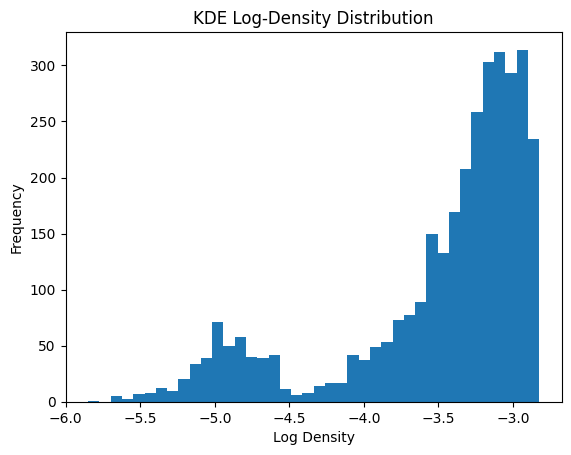

In [6]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(X_scaled)

log_density = kde.score_samples(X_scaled)

plt.figure()
plt.hist(log_density, bins=40)
plt.xlabel("Log Density")
plt.ylabel("Frequency")
plt.title("KDE Log-Density Distribution")
plt.show()

4. Gaussian Mixture Model (GMM)

We now model the data as a mixture of multivariate Gaussian distributions.

The Gaussian Mixture Model assumes:

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

where:

- $K$ = number of clusters  
- $\pi_k$ = mixture weights  
- $\mu_k$ = mean vector  
- $\Sigma_k$ = covariance matrix  

Unlike KMeans, GMM:

- Allows elliptical clusters
- Models feature correlations
- Provides probabilistic cluster membership

Because stellar evolution parameter space is correlated and anisotropic, GMM is physically justified.

5. Model Selection Using BIC

To determine the optimal number of clusters, we use the Bayesian Information Criterion (BIC):

$$
BIC = -2 \log L + k \log N
$$

where:

- $L$ = maximum likelihood
- $k$ = number of model parameters
- $N$ = number of data points

The optimal number of clusters minimizes the BIC.

In [12]:
# Replace zeros safely
X_safe = X + 1e-8

# Log transform
X_log = np.log10(X_safe)

# Drop any problematic rows
X_log = X_log.replace([np.inf, -np.inf], np.nan)
X_log = X_log.dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Final check
print("NaN present:", np.isnan(X_scaled).any())
print("Inf present:", np.isinf(X_scaled).any())

NaN present: False
Inf present: False


/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_po

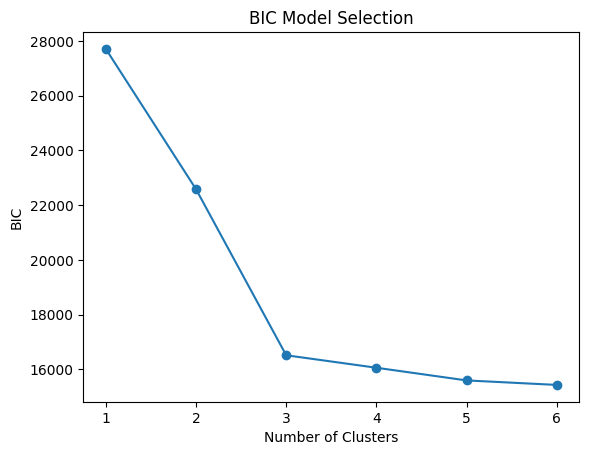

Optimal number of clusters: 6


In [7]:
bic_scores = []
K_range = range(1, 7)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        reg_covar=1e-6,
        random_state=42
    )
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(K_range, bic_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("BIC")
plt.title("BIC Model Selection")
plt.show()

optimal_k = K_range[np.argmin(bic_scores)]
print("Optimal number of clusters:", optimal_k)

6. Fit Final GMM Model

Using the optimal number of clusters determined by BIC, we now fit the final Gaussian Mixture Model.

We also compute the silhouette score to evaluate cluster separation.

In [8]:
gmm = GaussianMixture(
    n_components=optimal_k,
    covariance_type='full',
    reg_covar=1e-6,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
print("GMM Silhouette Score:", gmm_silhouette)

GMM Silhouette Score: 0.36574807806037957


/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_po

7. KMeans Clustering

For comparison, we also apply KMeans clustering.

KMeans minimizes:

$$
\sum_{k=1}^{K} \sum_{i \in C_k} ||x_i - \mu_k||^2
$$

Assumptions:

- Clusters are spherical
- Equal variance
- No covariance structure

Because binary evolution parameters are correlated, KMeans may perform worse than GMM.


In [9]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("KMeans Silhouette Score:", kmeans_silhouette)

KMeans Silhouette Score: 0.39000628475184623


/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:243: RuntimeWarning: invalid value encountered in matmul
  current_po

8. Algorithm Comparison

We compare clustering performance using the silhouette score:

$$
S = \frac{b - a}{\max(a, b)}
$$

where:

- $a$ = mean intra-cluster distance  
- $b$ = mean nearest-cluster distance  

Higher silhouette score → better separation.

In [10]:
print("GMM Silhouette:", gmm_silhouette)
print("KMeans Silhouette:", kmeans_silhouette)

GMM Silhouette: 0.36574807806037957
KMeans Silhouette: 0.39000628475184623


If GMM yields a higher silhouette score, this indicates that allowing full covariance modeling better captures the structure of the binary parameter space.

This would suggest that stellar evolution carves out anisotropic regions in initial condition space.

9. 3D Visualization of Clusters

To interpret the physical structure of the clusters, we visualize them in 3D log-parameter space:

- $\log_{10}(m_1)$
- $\log_{10}(m_2)$
- $\log_{10}(P_{\text{initial}})$

This allows us to inspect whether distinct evolutionary regions emerge.

/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/mpl_toolkits/mplot3d/proj3d.py:148: RuntimeWarning: divide by zero encountered in dot
  vecw = np.dot(M, vec.data)
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/mpl_toolkits/mplot3d/proj3d.py:148: RuntimeWarning: overflow encountered in dot
  vecw = np.dot(M, vec.data)
/Users/gaellejolesse/astro-env/lib/python3.13/site-packages/mpl_toolkits/mplot3d/proj3d.py:148: RuntimeWarning: invalid value encountered in dot
  vecw = np.dot(M, vec.data)


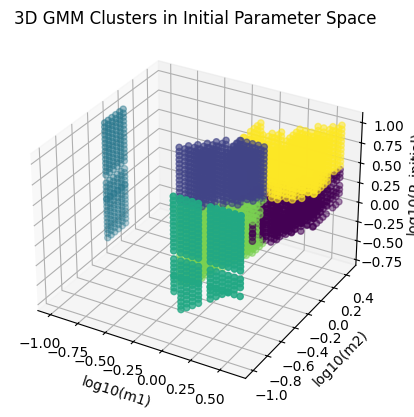

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_log["initial_m1"],
    X_log["initial_m2"],
    X_log["initial_period"],
    c=gmm_labels
)

ax.set_xlabel("log10(m1)")
ax.set_ylabel("log10(m2)")
ax.set_zlabel("log10(P_initial)")
ax.set_title("3D GMM Clusters in Initial Parameter Space")

plt.show()